In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:

main_columns = ['CBB_01', 'CBB_02', 'CBB_03','rGlyP_07', 'rGlyP_08','rGlyP_09',]
num_columns = ['CBB_UP_01', 'CBB_UP_02', 'CBB_UP_03', 'rGlyP_UP_07', 'rGlyP_UP_08', 'rGlyP_UP_09']
all_columns = main_columns + num_columns
cepa_CBB = ['CBB_01', 'CBB_02', 'CBB_03']
cepa_rGlyP = ['rGlyP_07', 'rGlyP_08','rGlyP_09']
cepa_CBB_peptido = ['CBB_UP_01', 'CBB_UP_02', 'CBB_UP_03']
cepa_rGlyP_peptido = ['rGlyP_UP_07', 'rGlyP_UP_08', 'rGlyP_UP_09']

In [3]:
data_protein = pd.read_csv('02_filtro_protein.groups.tsv', sep='\t', index_col=0)
#data_protein = pd.read_csv('01_filtro_protein.groups.tsv', sep='\t', index_col=0)

In [4]:
data_protein

,CBB_01,CBB_02,CBB_03,rGlyP_07,rGlyP_08,rGlyP_09,CBB_UP_01,CBB_UP_02,CBB_UP_03,rGlyP_UP_07,rGlyP_UP_08,rGlyP_UP_09
Protein.Group,,,,,,,,,,,,
O07451,26.392931,26.320032,26.349343,NaN,21.201639,NaN,29,34,33,0,4,0
O30338,21.483608,21.568191,21.640735,21.467156,21.488334,21.483205,3,3,3,3,3,3
O87816,27.211578,27.108774,27.220774,27.499516,27.533413,27.568671,12,9,12,12,14,12
P14611,32.618989,32.412991,32.299652,32.993430,32.812984,32.921867,68,66,69,68,69,69
P14697,27.982094,28.089317,28.277010,28.806529,28.993055,29.002088,40,41,41,43,43,43
...,...,...,...,...,...,...,...,...,...,...,...,...
Q7WXU0,26.380829,26.527723,26.582587,24.817430,24.982458,24.917217,8,7,8,7,7,6
Q83WS0,NaN,NaN,NaN,33.212505,33.180884,33.246544,0,0,0,84,83,84
Q8KLU8,22.928322,22.878103,22.630112,23.168801,23.044661,23.121074,5,5,5,5,6,5


In [5]:
data_protein[main_columns]

,CBB_01,CBB_02,CBB_03,rGlyP_07,rGlyP_08,rGlyP_09
Protein.Group,,,,,,
O07451,26.392931,26.320032,26.349343,NaN,21.201639,NaN
O30338,21.483608,21.568191,21.640735,21.467156,21.488334,21.483205
O87816,27.211578,27.108774,27.220774,27.499516,27.533413,27.568671
P14611,32.618989,32.412991,32.299652,32.993430,32.812984,32.921867
P14697,27.982094,28.089317,28.277010,28.806529,28.993055,29.002088
...,...,...,...,...,...,...
Q7WXU0,26.380829,26.527723,26.582587,24.817430,24.982458,24.917217
Q83WS0,NaN,NaN,NaN,33.212505,33.180884,33.246544
Q8KLU8,22.928322,22.878103,22.630112,23.168801,23.044661,23.121074


Para hacer los gráficos de distribución hay que transformar los datos a una proteina y muestra por fila

In [6]:
df_long = data_protein[main_columns].reset_index().melt(id_vars=['Protein.Group'], 
                            var_name='Muestra', 
                            value_name='Intensidad')

df_long['Grupo'] = df_long['Muestra'].str.split('_').str[0]

In [7]:
df_long

,Protein.Group,Muestra,Intensidad,Grupo
0,O07451,CBB_01,26.392931,CBB
1,O30338,CBB_01,21.483608,CBB
2,O87816,CBB_01,27.211578,CBB
3,P14611,CBB_01,32.618989,CBB
4,P14697,CBB_01,27.982094,CBB
...,...,...,...,...
17521,Q7WXU0,rGlyP_09,24.917217,rGlyP
17522,Q83WS0,rGlyP_09,33.246544,rGlyP
17523,Q8KLU8,rGlyP_09,23.121074,rGlyP
17524,Q9X6U2,rGlyP_09,29.616149,rGlyP


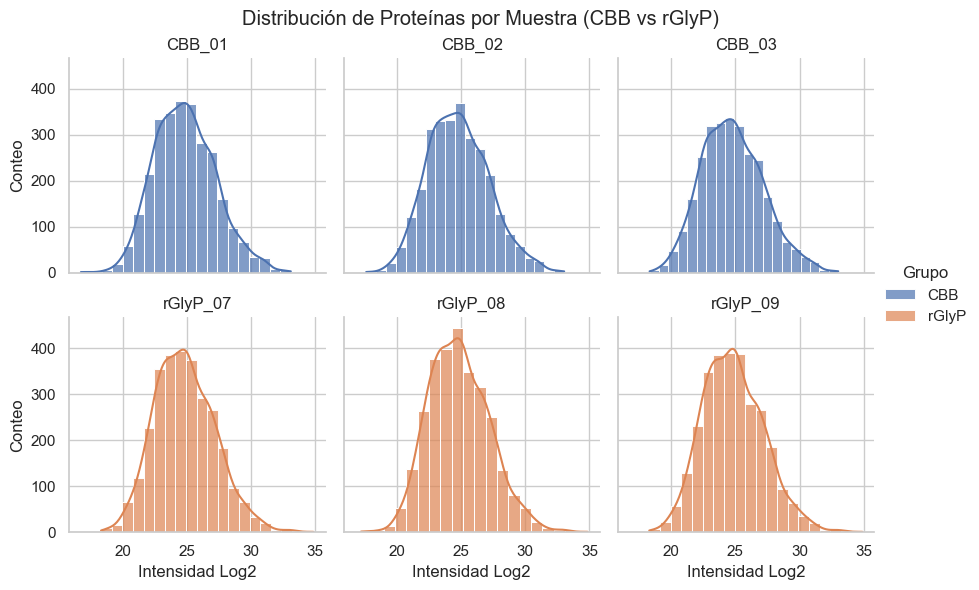

In [8]:
g = sns.FacetGrid(df_long, col="Muestra", hue="Grupo", col_wrap=3, sharex=True, height=3)
g.map_dataframe(sns.histplot, x="Intensidad", kde=True, bins=20, alpha=0.7)
g.set_axis_labels("Intensidad Log2", "Conteo")
g.set_titles(col_template="{col_name}")
g.add_legend()
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distribución de Proteínas por Muestra (CBB vs rGlyP)')
plt.savefig('03-distribucion-antes-imputar.png', dpi=300)
plt.show()

In [9]:
data_protein[main_columns]

,CBB_01,CBB_02,CBB_03,rGlyP_07,rGlyP_08,rGlyP_09
Protein.Group,,,,,,
O07451,26.392931,26.320032,26.349343,NaN,21.201639,NaN
O30338,21.483608,21.568191,21.640735,21.467156,21.488334,21.483205
O87816,27.211578,27.108774,27.220774,27.499516,27.533413,27.568671
P14611,32.618989,32.412991,32.299652,32.993430,32.812984,32.921867
P14697,27.982094,28.089317,28.277010,28.806529,28.993055,29.002088
...,...,...,...,...,...,...
Q7WXU0,26.380829,26.527723,26.582587,24.817430,24.982458,24.917217
Q83WS0,NaN,NaN,NaN,33.212505,33.180884,33.246544
Q8KLU8,22.928322,22.878103,22.630112,23.168801,23.044661,23.121074


In [10]:
data_protein_imputado = data_protein.copy()
for col in main_columns:
    data_protein_imputado[col+'_imputado'] = 'No'
    mask = data_protein[col].isna()
    n_missing = mask.sum()
    if n_missing > 0:
        mu = data_protein[col].mean()
        sigma = data_protein[col].std()
        mu_impute = mu - (1.8 * sigma) # Parámetros Perseo: desplazar la media 1.8 sigmas hacia abajo 
        sigma_impute = sigma * 0.3 # y reducir el ancho de la distribución al 30% (0.3)
        valores_imputados = np.random.normal(loc=mu_impute, scale=sigma_impute, size=n_missing)
        data_protein_imputado.loc[mask, col] = valores_imputados
        data_protein_imputado.loc[mask, col+'_imputado'] = 'Si'

In [11]:
data_protein_imputado

,CBB_01,CBB_02,CBB_03,rGlyP_07,rGlyP_08,rGlyP_09,CBB_UP_01,CBB_UP_02,CBB_UP_03,rGlyP_UP_07,rGlyP_UP_08,rGlyP_UP_09,CBB_01_imputado,CBB_02_imputado,CBB_03_imputado,rGlyP_07_imputado,rGlyP_08_imputado,rGlyP_09_imputado
Protein.Group,,,,,,,,,,,,,,,,,,
O07451,26.392931,26.320032,26.349343,21.323830,21.201639,20.923588,29,34,33,0,4,0,No,No,No,Si,No,Si
O30338,21.483608,21.568191,21.640735,21.467156,21.488334,21.483205,3,3,3,3,3,3,No,No,No,No,No,No
O87816,27.211578,27.108774,27.220774,27.499516,27.533413,27.568671,12,9,12,12,14,12,No,No,No,No,No,No
P14611,32.618989,32.412991,32.299652,32.993430,32.812984,32.921867,68,66,69,68,69,69,No,No,No,No,No,No
P14697,27.982094,28.089317,28.277010,28.806529,28.993055,29.002088,40,41,41,43,43,43,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q7WXU0,26.380829,26.527723,26.582587,24.817430,24.982458,24.917217,8,7,8,7,7,6,No,No,No,No,No,No
Q83WS0,22.279368,20.331921,20.976532,33.212505,33.180884,33.246544,0,0,0,84,83,84,Si,Si,Si,No,No,No
Q8KLU8,22.928322,22.878103,22.630112,23.168801,23.044661,23.121074,5,5,5,5,6,5,No,No,No,No,No,No


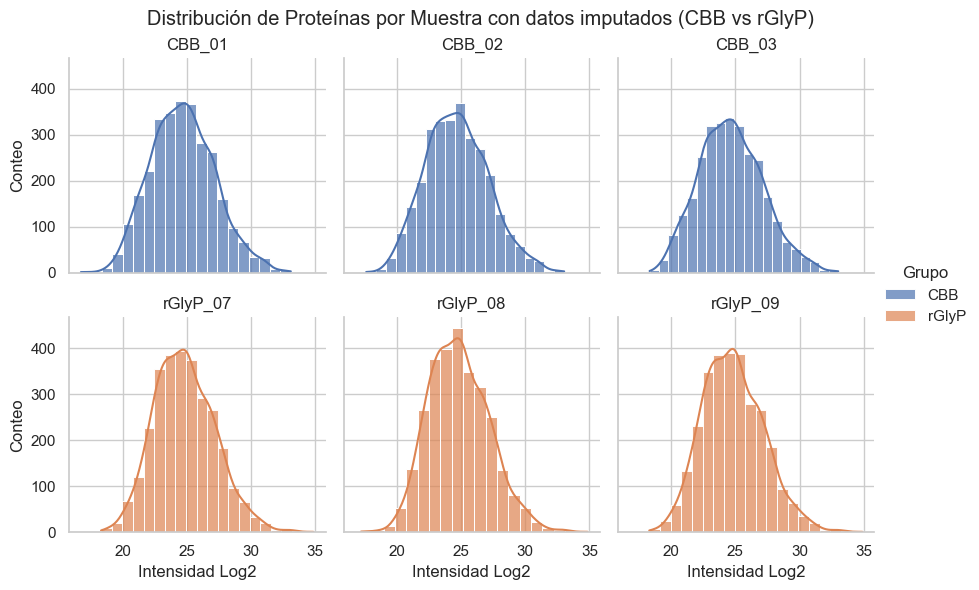

In [12]:
df_long = data_protein_imputado[main_columns].reset_index().melt(id_vars=['Protein.Group'], 
                            var_name='Muestra', 
                            value_name='Intensidad')

df_long['Grupo'] = df_long['Muestra'].str.split('_').str[0]
g = sns.FacetGrid(df_long, col="Muestra", hue="Grupo", col_wrap=3, sharex=True, height=3)
g.map_dataframe(sns.histplot, x="Intensidad", kde=True, bins=20, alpha=0.7)
g.set_axis_labels("Intensidad Log2", "Conteo")
g.set_titles(col_template="{col_name}")
g.add_legend()
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distribución de Proteínas por Muestra con datos imputados (CBB vs rGlyP)')
plt.savefig('03-distribucion-despues-imputar.png', dpi=300)
plt.show()

In [13]:
data_protein_imputado.to_csv('03_imputados_protein.groups.tsv', sep='\t')